In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
import os
warnings.filterwarnings('ignore')

In [2]:
# loading dataset via kaggle API
# ! kaggle datasets download -d kartik2112/fraud-detection -p "data/RAW" && tar -xf "data/RAW/fraud-detection.zip" -C "../data/RAW" && del "/..data/RAW/fraud-detection.zip"

In [3]:
# Load datasets
# Change to project folder
os.chdir(r"C:\Users\YASH\Saved Games\codsoft\Task-2")

# Confirm
print("Now working in:", os.getcwd())

print("Loading datasets...")
fraudtrain_df = pd.read_csv("data/RAW/fraudTrain.csv")
fraudtest_df = pd.read_csv("data/RAW/fraudTest.csv")

print(f"Training data shape: {fraudtrain_df.shape}")
print(f"Test data shape: {fraudtest_df.shape}")

Now working in: C:\Users\YASH\Saved Games\codsoft\Task-2
Loading datasets...
Training data shape: (1296675, 23)
Test data shape: (555719, 23)


In [4]:
fraudtest_df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [5]:
# Function to preprocess dataset
def preprocess_data(df):
    """
    Preprocess fraud detection dataset
    """
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    df['hour'] = df['trans_date_trans_time'].dt.hour
    df['day'] = df['trans_date_trans_time'].dt.day
    df['month'] = df['trans_date_trans_time'].dt.month

    # Calculate distance between customer and merchant
    df['distance'] = np.sqrt(
    (df['lat'] - df['merch_lat'])**2 + 
    (df['long'] - df['merch_long'])**2
    )
    
    # Drop unnecessary columns
    cols_to_drop = [
        'Unnamed: 0', 'trans_date_trans_time', 'cc_num', 
        'first', 'last', 'unix_time', 'street', 'trans_num','state', 
        'job', 'city','zip','lat', 'long', 'merch_lat', 'merch_long'
    ]
    df = df.drop(columns=cols_to_drop, errors='ignore')
    
    # Calculate age from dob
    df['dob'] = pd.to_datetime(df['dob'], errors='coerce')
    df['age'] = (datetime.now() - df['dob']).dt.days // 365
    df = df.drop(columns=['dob'])
    
    # Identify categorical and numerical columns
    categorical_cols = ['merchant', 'category', 'gender']
    numerical_cols = ['amt', 'city_pop', 'age', 'distance']
    
    # Label encode categorical variables
    label_encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le
    
    # Standardize numerical features
    scaler = StandardScaler()
    df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
    
    return df, label_encoders, scaler


In [6]:
preprocess_data(fraudtrain_df.head())

(   merchant  category       amt  gender  city_pop  is_fraud  hour  day  month  \
 0         4         3 -1.043024       0  0.915883         0     0    1      1   
 1         0         2  0.309083       0 -1.089971         0     0    1      1   
 2         3         0  1.801611       1  1.310939         0     0    1      1   
 3         2         1 -0.513737       1 -0.016905         0     0    1      1   
 4         1         4 -0.553933       1 -1.119945         0     0    1      1   
 
    distance       age  
 0  0.352993 -1.151781  
 1 -1.977186 -0.175695  
 2  0.752723  1.386042  
 3  0.535258  0.897999  
 4  0.336212 -0.956564  ,
 {'merchant': LabelEncoder(),
  'category': LabelEncoder(),
  'gender': LabelEncoder()},
 StandardScaler())

In [7]:
# Preprocess training data
print("\nPreprocessing training data...")
fraudtrain_processed, train_encoders, train_scaler = preprocess_data(fraudtrain_df.copy())

# Preprocess test data
print("Preprocessing test data...")
fraudtest_processed, test_encoders, test_scaler = preprocess_data(fraudtest_df.copy())


Preprocessing training data...
Preprocessing test data...


In [8]:
# Check class imbalance
print("\n" + "="*50)
print("CLASS DISTRIBUTION - TRAINING DATA")
print("="*50)
print(fraudtrain_processed['is_fraud'].value_counts())
print("\nProportions:")
print(fraudtrain_processed['is_fraud'].value_counts(normalize=True))



CLASS DISTRIBUTION - TRAINING DATA
is_fraud
0    1289169
1       7506
Name: count, dtype: int64

Proportions:
is_fraud
0    0.994211
1    0.005789
Name: proportion, dtype: float64


In [9]:
print("\n" + "="*50)
print("CLASS DISTRIBUTION - TEST DATA")
print("="*50)
print(fraudtest_processed['is_fraud'].value_counts())
print("\nProportions:")
print(fraudtest_processed['is_fraud'].value_counts(normalize=True))


CLASS DISTRIBUTION - TEST DATA
is_fraud
0    553574
1      2145
Name: count, dtype: int64

Proportions:
is_fraud
0    0.99614
1    0.00386
Name: proportion, dtype: float64


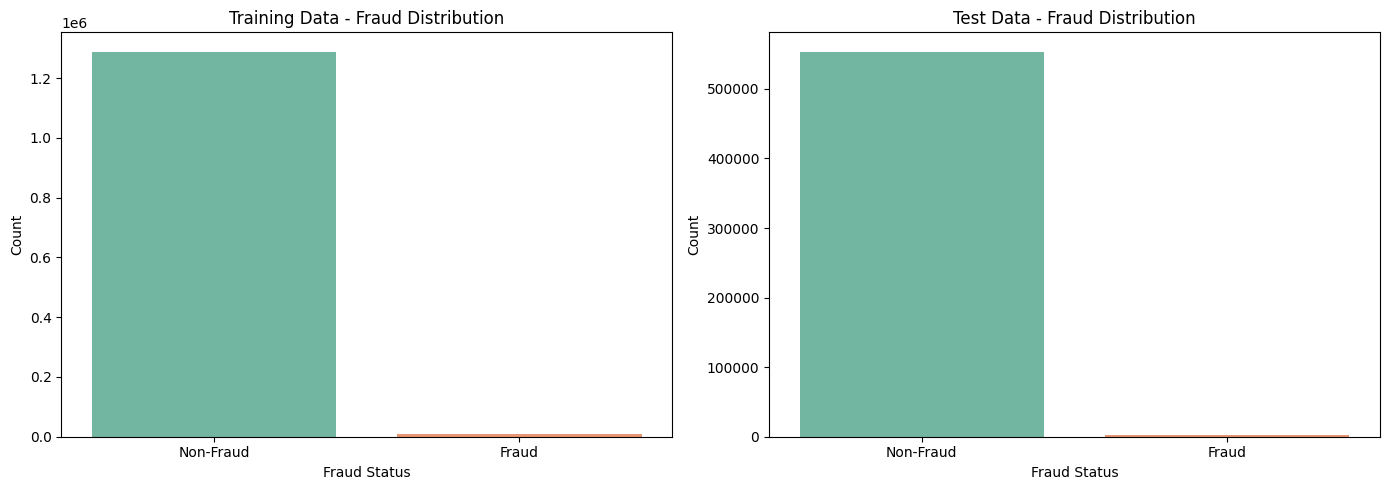

In [10]:
# Visualize fraud distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training data
sns.countplot(x='is_fraud', data=fraudtrain_processed, palette='Set2', ax=axes[0])
axes[0].set_xlabel('Fraud Status')
axes[0].set_ylabel('Count')
axes[0].set_title('Training Data - Fraud Distribution')
axes[0].set_xticklabels(['Non-Fraud', 'Fraud'])

# Test data
sns.countplot(x='is_fraud', data=fraudtest_processed, palette='Set2', ax=axes[1])
axes[1].set_xlabel('Fraud Status')
axes[1].set_ylabel('Count')
axes[1].set_title('Test Data - Fraud Distribution')
axes[1].set_xticklabels(['Non-Fraud', 'Fraud'])

plt.tight_layout()
plt.savefig('figures_image/fraud_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


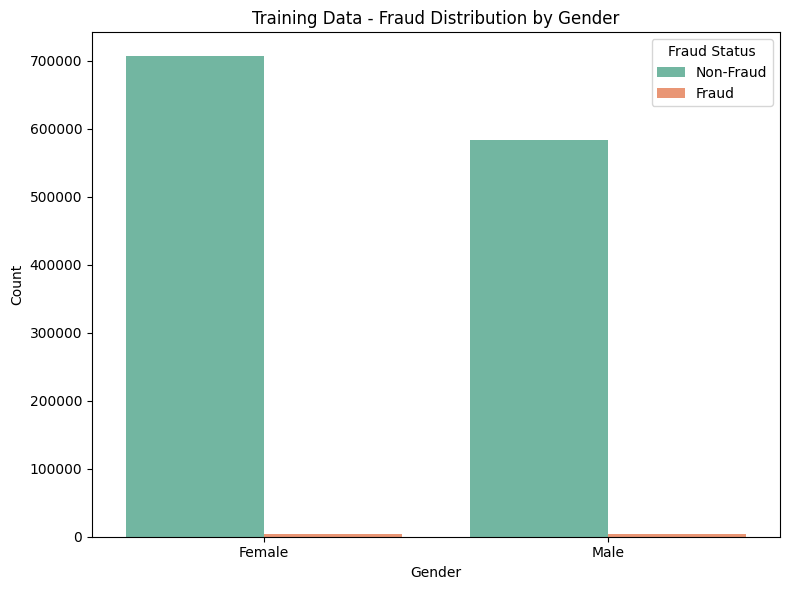

In [11]:
# Visualize fraud by gender (training data)
plt.figure(figsize=(8, 6))
gender_labels = ['Female', 'Male']
sns.countplot(x='gender', hue='is_fraud', data=fraudtrain_processed, palette='Set2')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Training Data - Fraud Distribution by Gender')
plt.xticks([0, 1], gender_labels)
plt.legend(title='Fraud Status', labels=['Non-Fraud', 'Fraud'])
plt.tight_layout()
plt.savefig('figures_image/fraud_by_gender.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# Check for missing values
print("\n" + "="*50)
print("MISSING VALUES CHECK")
print("="*50)
print("\nTraining data missing values:")
print(fraudtrain_processed.isnull().sum())
print("\nTest data missing values:")
print(fraudtest_processed.isnull().sum())


MISSING VALUES CHECK

Training data missing values:
merchant    0
category    0
amt         0
gender      0
city_pop    0
is_fraud    0
hour        0
day         0
month       0
distance    0
age         0
dtype: int64

Test data missing values:
merchant    0
category    0
amt         0
gender      0
city_pop    0
is_fraud    0
hour        0
day         0
month       0
distance    0
age         0
dtype: int64


In [13]:
# Summary statistics
print("\n" + "="*50)
print("PROCESSED DATA INFO")
print("="*50)
print("\nTraining data:")
print(fraudtrain_processed.info())
print("\nTest data:")
print(fraudtest_processed.info())



PROCESSED DATA INFO

Training data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 11 columns):
 #   Column    Non-Null Count    Dtype  
---  ------    --------------    -----  
 0   merchant  1296675 non-null  int64  
 1   category  1296675 non-null  int64  
 2   amt       1296675 non-null  float64
 3   gender    1296675 non-null  int64  
 4   city_pop  1296675 non-null  float64
 5   is_fraud  1296675 non-null  int64  
 6   hour      1296675 non-null  int32  
 7   day       1296675 non-null  int32  
 8   month     1296675 non-null  int32  
 9   distance  1296675 non-null  float64
 10  age       1296675 non-null  float64
dtypes: float64(4), int32(3), int64(4)
memory usage: 94.0 MB
None

Test data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 11 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   merchant  555719 non-null  int64  
 1   cat

In [14]:
# Display first few rows
print("\n" + "="*50)
print("SAMPLE DATA (First 5 rows)")
print("="*50)
print("\nTraining data:")
print(fraudtrain_processed.head())
print("\nTest data:")
print(fraudtest_processed.head())


SAMPLE DATA (First 5 rows)

Training data:
   merchant  category       amt  gender  city_pop  is_fraud  hour  day  month  \
0       514         8 -0.407826       0 -0.282589         0     0    1      1   
1       241         4  0.230039       0 -0.293670         0     0    1      1   
2       390         0  0.934149       1 -0.280406         0     0    1      1   
3       360         2 -0.158132       1 -0.287742         0     0    1      1   
4       297         9 -0.177094       1 -0.293835         0     0    1      1   

   distance       age  
0  0.376362 -0.837670  
1 -1.732586 -0.262961  
2  0.738140  0.656575  
3  0.541322  0.369220  
4  0.361173 -0.722728  

Test data:
   merchant  category       amt  gender  city_pop  is_fraud  hour  day  month  \
0       319        10 -0.424463       1  0.816521         0    12   21      6   
1       591        10 -0.252337       0 -0.292685         0    12   21      6   
2       611         5 -0.179353       0 -0.178853         0    12   21

In [15]:
# merging the train dataset and test dataset
fraud_df = pd.concat([fraudtrain_processed, fraudtest_processed], axis=0)
 

In [16]:
# Save processed datasets
print("\n" + "="*50)
print("SAVING PROCESSED DATA")
print("="*50)
fraudtrain_processed.to_csv("data/processed/fraudTrain.csv", index=False)
fraudtest_processed.to_csv("data/processed/fraudTest.csv", index=False)
print("✓ Processed training data saved to: ../data/processed/fraudTrain.csv")
print("✓ Processed test data saved to: ../data/processed/fraudTest.csv")


SAVING PROCESSED DATA
✓ Processed training data saved to: ../data/processed/fraudTrain.csv
✓ Processed test data saved to: ../data/processed/fraudTest.csv
